# Task IX.A: Foundation Model for Strong Gravitational Lensing

In this notebook I implement a **Masked Autoencoder (MAE)** based approach for learning representations of strong gravitational lensing images. The goal is to first learn the general structure of lensing systems using **self-supervised pretraining**, and then fine-tune the model for a **three-class dark matter classification task**.

The dataset contains simulated lensing images belonging to three classes:

- **no_sub** - smooth lens with no dark matter substructure  
- **cdm** - cold dark matter subhalos that introduce localized distortions  
- **axion** - axion-like dark matter producing wave-like perturbations  

My approach follows two stages. First, I train a **Masked Autoencoder only on the `no_sub` samples** so the encoder can learn the underlying geometry of Einstein rings and lensing arcs. After this representation learning stage, I reuse the pretrained encoder and attach a **classification head** to distinguish between the three dark matter scenarios.

To evaluate the model, I use **ROC curves, AUC scores, confusion matrices, and feature space visualizations**. These analyses help understand not only how well the model performs, but also how it represents different lensing structures internally.

The experiments are trained locally using **PyTorch on an RTX 4050 GPU**, allowing efficient training of the transformer-based architecture.

In [1]:
import os
import sys
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm


CONFIG = {
    "seed": 42,
    "image_size": 64,
    "patch_size": 4,
    "num_patches": 256,
    "embedding_dim": 192,
    "encoder_layers": 6,
    "attention_heads": 3,
    "decoder_layers": 4, 
    "mask_ratio": 0.90,  # 90% masking for high-fidelity pretraining
    "batch_size": 64,
    "pretrain_epochs": 30,
    "finetune_epochs": 20,
    "lr_pretrain": 1.5e-4,
    "lr_finetune": 1e-4,
    "weight_decay": 0.05,
    "dropout": 0.1,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["seed"])
print(f"Using device: {CONFIG['device']}")

Using device: cuda




The dataset consists of simulated strong lensing images stored as `.npy` files. Each image is a **64×64 grayscale simulation** and belongs to one of three dark matter scenarios:

- **no_sub**
- **cdm**
- **axion**

To prepare the dataset:

- Each image is normalized to the range **[0, 1]** using min-max scaling.
- A **stratified train/test split** is used so that all classes remain balanced.
- For the self-supervised stage, only the **no_sub images** are used to train the masked autoencoder.

The idea behind this choice is that smooth lenses provide a clean baseline representation of gravitational arcs. Once the model understands the global lensing structure, it becomes easier to detect deviations caused by dark matter substructure.

In [2]:
class LensingDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels
        
    def __len__(self):
        return len(self.paths)
        
    def __getitem__(self, idx):
        data = np.load(self.paths[idx], allow_pickle=True)
        img = data[0] if isinstance(data, (list, tuple, np.ndarray)) and len(data) == 2 else data
        img = img.astype(np.float32)
        if img.max() > img.min():
            img = (img - img.min()) / (img.max() - img.min())
        return torch.from_numpy(img).unsqueeze(0), self.labels[idx]

DATA_PATH = r'd:\tests\DeepLense-ML4SCI-GSoC26-Tests\data\foundation\Dataset'
CLASSES = ['no_sub', 'cdm', 'axion']

all_paths, all_labels = [], []
for i, cls in enumerate(CLASSES):
    paths = glob.glob(os.path.join(DATA_PATH, cls, '*.npy'))
    all_paths.extend(paths)
    all_labels.extend([i] * len(paths))

tr_paths, ts_paths, tr_labs, ts_labs = train_test_split(
    all_paths, all_labels, test_size=0.1, stratify=all_labels, random_state=CONFIG["seed"]
)

mae_paths = [p for p, l in zip(tr_paths, tr_labs) if l == 0]
mae_labs = [0] * len(mae_paths)

print("Example file:", all_paths[0])
# RTX 4050 Performance Params
dl_params = {
    "batch_size": CONFIG["batch_size"], 
    "num_workers": 0, 
    "pin_memory": True
}

train_loader = DataLoader(LensingDataset(tr_paths, tr_labs), shuffle=True, **dl_params)
test_loader = DataLoader(LensingDataset(ts_paths, ts_labs), shuffle=False, **dl_params)
mae_loader = DataLoader(LensingDataset(mae_paths, mae_labs), shuffle=True, **dl_params)

print(f"Dataset Loaded. MAE: {len(mae_paths)}, Train: {len(tr_paths)}, Test: {len(ts_paths)}")

Example file: d:\tests\DeepLense-ML4SCI-GSoC26-Tests\data\foundation\Dataset\no_sub\no_sub_sim_100007394254046077438189589177507789788.npy
Dataset Loaded. MAE: 26504, Train: 80193, Test: 8911


### Dataset Class Distribution

Before training the model, it is useful to verify that the dataset split is balanced across classes.

A large imbalance could bias the classifier and make the evaluation metrics misleading. The following visualization compares the number of samples for each class in both the training and test sets.

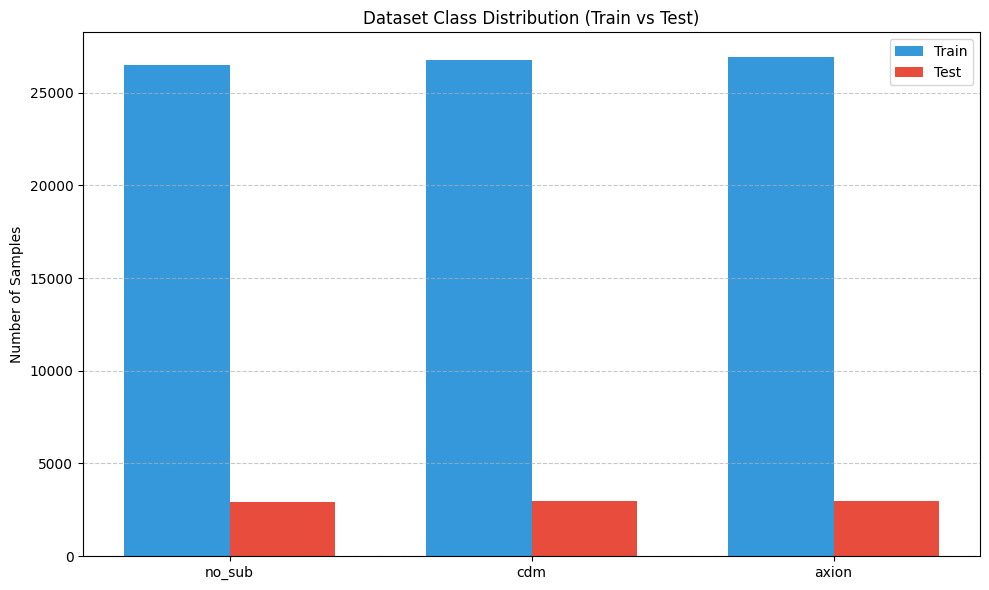

no_sub     | Train: 26504 | Test: 2945 
cdm        | Train: 26783 | Test: 2976 
axion      | Train: 26906 | Test: 2990 


In [3]:
# Verify Class Distribution
train_counts = [tr_labs.count(i) for i in range(3)]
test_counts = [ts_labs.count(i) for i in range(3)]

x = np.arange(len(CLASSES))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_counts, width, label='Train', color='#3498db')
ax.bar(x + width/2, test_counts, width, label='Test', color='#e74c3c')

ax.set_ylabel('Number of Samples')
ax.set_title('Dataset Class Distribution (Train vs Test)')
ax.set_xticks(x, CLASSES)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

for i, cls in enumerate(CLASSES):
    print(f"{cls:<10} | Train: {train_counts[i]:<5} | Test: {test_counts[i]:<5}")

### Patch Representation and Masking Strategy

Vision Transformers process images as sequences of **patch tokens** instead of raw pixels.

For a **64×64 image** with a **patch size of 4×4**, the image is divided into **256 patches**. Each patch becomes a token that is passed into the transformer encoder.

During MAE pretraining, a large portion of these patches is randomly hidden. In this experiment a **90% masking ratio** is used, meaning that the model only sees a small fraction of the image.

This forces the encoder to rely on the **global structure of the lensing arcs** instead of local pixel patterns in order to reconstruct the missing regions.

In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=1, embed_dim=192):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

def random_masking(x, mask_ratio):
    N, L, D = x.shape
    len_keep = int(L * (1 - mask_ratio))
    noise = torch.rand(N, L, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]
    x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
    mask = torch.ones([N, L], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_masked, mask, ids_restore

### MAE Architecture Design

The Masked Autoencoder used here follows the standard **encoder–decoder design** introduced for MAE models.

The architecture consists of two main components:

**Encoder**

- Receives only the visible patches.
- Implemented using a Vision Transformer.
- Learns compact representations of the lensing structure.

**Decoder**

- Receives both encoded visible patches and mask tokens.
- Attempts to reconstruct the missing image regions.

The model is trained using **Mean Squared Error (MSE)** between the reconstructed patches and the original image patches.

Because the encoder only processes visible tokens, this design is computationally efficient even when a large percentage of the image is masked.

In [5]:
class MaskedAutoencoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embed = PatchEmbedding(config["image_size"], config["patch_size"], 1, config["embedding_dim"])
        
        # Encoder
        self.cls_token = nn.Parameter(torch.zeros(1, 1, config["embedding_dim"]))
        self.pos_embed = nn.Parameter(torch.zeros(1, config["num_patches"] + 1, config["embedding_dim"]))
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=config["embedding_dim"], nhead=config["attention_heads"], 
                                       dim_feedforward=int(config["embedding_dim"]*4), dropout=config["dropout"], 
                                       batch_first=True, norm_first=True),
            num_layers=config["encoder_layers"]
        )
        
        # Decoder
        self.mask_token = nn.Parameter(torch.zeros(1, 1, config["embedding_dim"]))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, config["num_patches"] + 1, config["embedding_dim"]))
        self.decoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=config["embedding_dim"], nhead=config["attention_heads"], 
                                       batch_first=True, norm_first=True),
            num_layers=config["decoder_layers"]
        )
        self.head = nn.Linear(config["embedding_dim"], config["patch_size"]**2)
        
        
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward_encoder(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = random_masking(x, self.config["mask_ratio"]) 
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat((cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        return self.encoder(x), mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = x[:, 1:, :]
        mask_tokens = self.mask_token.expand(x.shape[0], ids_restore.shape[1] - x.shape[1], -1)
        x_all = torch.gather(torch.cat([x, mask_tokens], dim=1), dim=1, 
                             index=ids_restore.unsqueeze(-1).expand(-1, -1, x.shape[2]))
        x = torch.cat([self.cls_token.expand(x_all.shape[0], -1, -1), x_all], dim=1) + self.decoder_pos_embed
        return self.head(self.decoder(x)[:, 1:, :])

    def forward(self, imgs):
        latent, mask, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        
        
        p = self.config["patch_size"]
        h = self.config["image_size"] // p
        w = self.config["image_size"] // p
        target = imgs.reshape(imgs.shape[0], 1, h, p, w, p)
        target = target.permute(0, 2, 4, 3, 5, 1).reshape(imgs.shape[0], -1, p*p)
        
        target = (target - target.mean(dim=-1, keepdim=True)) / (target.var(dim=-1, keepdim=True) + 1e-6)**0.5
        loss = (pred - target) ** 2
        return (loss.mean(dim=-1) * mask).sum() / mask.sum(), pred, mask


class MAEClassifier(nn.Module):
    def __init__(self, mae_model, config):
        super().__init__()
        self.patch_embed = mae_model.patch_embed
        self.encoder = mae_model.encoder
        self.cls_token = mae_model.cls_token
        self.pos_embed = mae_model.pos_embed
        self.head = nn.Sequential(
            nn.LayerNorm(config["embedding_dim"]),
            nn.Linear(config["embedding_dim"], 3)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        cls = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat((cls.expand(x.shape[0], -1, -1), x), dim=1)
        x = self.encoder(x)
        return self.head(x[:, 0])

### MAE Self-Supervised Pretraining

In the first stage, the MAE model is trained only on the **no_sub images**.

At each iteration:

1. A random subset of patches is masked.
2. The encoder processes the visible tokens.
3. The decoder attempts to reconstruct the masked regions.

The reconstruction loss encourages the encoder to learn the **global geometry of strong lensing arcs**, including ring symmetry and brightness patterns.

This representation learning stage provides a useful initialization for the later classification task.

In [6]:
# Instantiate and optimize model
mae_model = MaskedAutoencoder(CONFIG).to(CONFIG["device"])

# if hasattr(torch, "compile"):
#     try: mae_model = torch.compile(mae_model)
#     except: pass

optimizer = optim.AdamW(mae_model.parameters(), lr=CONFIG["lr_pretrain"], weight_decay=CONFIG["weight_decay"])
scaler = GradScaler()

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["pretrain_epochs"])
mae_history = []

best_mae_loss = float('inf')
print(f"Beginning MAE Pretraining for {CONFIG['pretrain_epochs']} epochs...")
print("Starting MAE training loop...")

for epoch in range(CONFIG["pretrain_epochs"]):
    mae_model.train()
    total_loss = 0
    pbar = tqdm(mae_loader, desc=f"Training", unit="batch", leave=True, file=sys.stdout)
    for imgs, _ in pbar:
        imgs = imgs.to(CONFIG["device"], non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        # FIX 5: device_type="cuda"
        with autocast(device_type="cuda"):
            loss, _, _ = mae_model(imgs)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(mae_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(mae_loader)
    mae_history.append(avg_loss)
    scheduler.step() # FIX 6
    
    if avg_loss < best_mae_loss:
        best_mae_loss = avg_loss
        WEIGHT_PATH = os.path.join(r'd:\tests\DeepLense-ML4SCI-GSoC26-Tests\model')
        os.makedirs(WEIGHT_PATH, exist_ok=True)
        torch.save(mae_model.state_dict(), os.path.join(WEIGHT_PATH, 'mae_pretrained.pth'))
        print(f"--> Saved Best MAE Model (Loss: {best_mae_loss:.4f})")
    
    print(f"Epoch [{epoch+1:02d}/{CONFIG['pretrain_epochs']:02d}] | MAE Loss: {avg_loss:.4f}")
    sys.stdout.flush()

d:\tests\DeepLense-ML4SCI-GSoC26-Tests\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Beginning MAE Pretraining for 30 epochs...
Starting MAE training loop...
Training: 100%|██████████| 415/415 [02:10<00:00,  3.18batch/s, loss=0.1016]
--> Saved Best MAE Model (Loss: 0.1457)
Epoch [01/30] | MAE Loss: 0.1457
Training: 100%|██████████| 415/415 [00:46<00:00,  8.91batch/s, loss=0.0887]
--> Saved Best MAE Model (Loss: 0.0949)
Epoch [02/30] | MAE Loss: 0.0949
Training: 100%|██████████| 415/415 [00:46<00:00,  8.95batch/s, loss=0.0774]
--> Saved Best MAE Model (Loss: 0.0912)
Epoch [03/30] | MAE Loss: 0.0912
Training: 100%|██████████| 415/415 [00:46<00:00,  8.91batch/s, loss=0.0456]
--> Saved Best MAE Model (Loss: 0.0812)
Epoch [04/30] | MAE Loss: 0.0812
Training: 100%|██████████| 415/415 [00:46<00:00,  8.94batch/s, loss=0.0563]
--> Saved Best MAE Model (Loss: 0.0608)
Epoch [05/30] | MAE Loss: 0.0608
Training: 100%|██████████| 415/415 [00:46<00:00,  8.85batch/s, loss=0.0257]
--> Saved Best MAE Model (Loss: 0.0540)
Epoch [06/30] | MAE Loss: 0.0540
Training: 100%|██████████| 415/41

### Transition to Supervised Classification

After pretraining, the decoder is no longer needed. The encoder is reused as a **feature extractor**.

A small classification head is attached to the **CLS token**, which represents the entire image.

The model is then fine-tuned on the full dataset containing all three classes. During this stage, the encoder adjusts its representations to capture subtle differences between the dark matter scenarios.

In [7]:
clf_model = MAEClassifier(mae_model, CONFIG).to(CONFIG["device"])
# if hasattr(torch, "compile"):
#     try: clf_model = torch.compile(clf_model)
#     except: pass

optimizer_ft = optim.AdamW(clf_model.parameters(), lr=CONFIG["lr_finetune"], weight_decay=CONFIG["weight_decay"])
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=CONFIG["finetune_epochs"])
clf_history = []

best_acc = 0.0
print(f"Fine-tuning Classifier for {CONFIG['finetune_epochs']} epochs...")
print("Starting classifier fine-tuning...")

for epoch in range(CONFIG["finetune_epochs"]):
    clf_model.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f"Training", unit="batch", leave=True, file=sys.stdout)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(CONFIG["device"], non_blocking=True), labels.to(CONFIG["device"], non_blocking=True)
        optimizer_ft.zero_grad(set_to_none=True)
        with autocast(device_type="cuda"):
            logits = clf_model(imgs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer_ft)
        scaler.update()
        total_train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    clf_model.eval()
    all_probs, all_labels = [], []
    val_loss = 0
    with torch.no_grad(), autocast(device_type="cuda"):
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(CONFIG["device"]), labels.to(CONFIG["device"])
            logits = clf_model(imgs)
            val_loss += criterion(logits, labels).item()
            all_probs.append(torch.softmax(logits, dim=1).cpu())
            all_labels.append(labels.cpu())
    
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    clf_history.append(avg_train_loss)
    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(labels, probs.argmax(axis=1))
    scheduler_ft.step()
    
    if acc > best_acc:
        best_acc = acc
        MODEL_SAVE_DIR = r'd:\tests\DeepLense-ML4SCI-GSoC26-Tests\model'
        os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
        torch.save(clf_model.state_dict(), os.path.join(MODEL_SAVE_DIR, 'mae_classifier_final.pth'))
        print(f"--> Saved Best Model (Acc: {best_acc*100:.2f}%)")
    
    print(f"Epoch [{epoch+1:02d}/{CONFIG['finetune_epochs']:02d}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc*100:.2f}%")
    sys.stdout.flush()

Fine-tuning Classifier for 20 epochs...
Starting classifier fine-tuning...
Training: 100%|██████████| 1254/1254 [08:21<00:00,  2.50batch/s, loss=0.1033]
--> Saved Best Model (Acc: 73.66%)
Epoch [01/20] | Train Loss: 0.8142 | Val Loss: 0.6749 | Val Acc: 73.66%
Training: 100%|██████████| 1254/1254 [05:35<00:00,  3.73batch/s, loss=0.0474]
--> Saved Best Model (Acc: 77.69%)
Epoch [02/20] | Train Loss: 0.4800 | Val Loss: 0.5694 | Val Acc: 77.69%
Training: 100%|██████████| 1254/1254 [07:13<00:00,  2.89batch/s, loss=0.0739]
Epoch [03/20] | Train Loss: 0.4209 | Val Loss: 0.6743 | Val Acc: 77.03%
Training: 100%|██████████| 1254/1254 [06:20<00:00,  3.29batch/s, loss=0.0008]
--> Saved Best Model (Acc: 82.37%)
Epoch [04/20] | Train Loss: 0.3791 | Val Loss: 0.4458 | Val Acc: 82.37%
Training: 100%|██████████| 1254/1254 [05:59<00:00,  3.48batch/s, loss=0.0444]
Epoch [05/20] | Train Loss: 0.3771 | Val Loss: 0.7563 | Val Acc: 74.72%
Training: 100%|██████████| 1254/1254 [05:56<00:00,  3.52batch/s, loss=


To validate the model's ability to distinguish subtle dark matter signatures, we evaluate it on the held-out test set. 
- **ROC Curves**: We plot Receiver Operating Characteristic curves for each class (`no_sub`, `cdm`, `axion`) to visualize the True Positive Rate vs False Positive Rate trade-offs.
- **AUC Scores**: The Area Under the Curve (AUC) provides a robust metric for classification performance, independent of class thresholds.
- **Confusion Matrix**: This matrix reveals specific misclassification trends, such as confusion between the two substructured classes.

Evaluating: 100%|██████████| 140/140 [00:05<00:00, 26.64it/s]


Final Evaluation Strategy Complete.

Per-class AUC scores:
----------------------
no_sub     : 0.9938
cdm        : 0.8412
axion      : 0.9720
----------------------
Macro AUC  : 0.9357


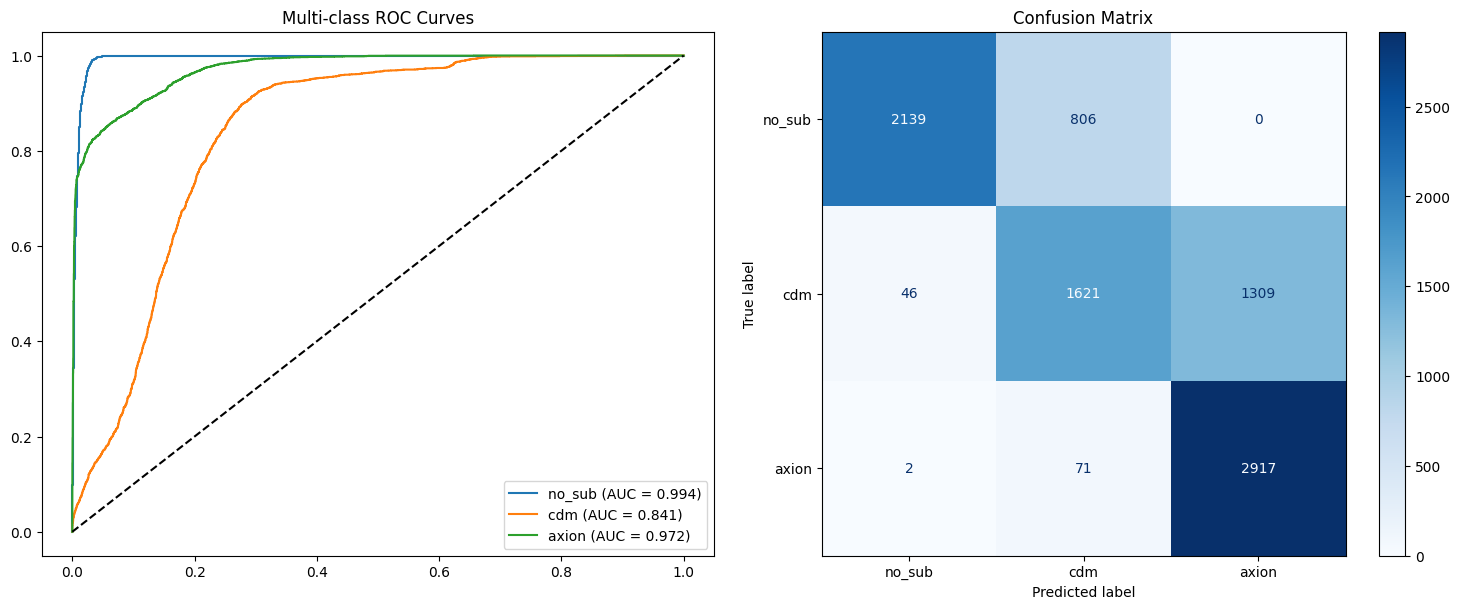

In [8]:
clf_model.eval()
all_probs, all_labels, all_preds = [], [], []

with torch.no_grad(), autocast(device_type="cuda"):
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(CONFIG["device"])
        logits = clf_model(imgs)
        all_probs.append(torch.softmax(logits, dim=1).cpu())
        all_labels.append(labels)
        all_preds.append(logits.argmax(1).cpu())

probs = torch.cat(all_probs).numpy()
labels = torch.cat(all_labels).numpy()
preds = torch.cat(all_preds).numpy()


macro_auc = roc_auc_score(labels, probs, multi_class="ovr")
print(f"Final Evaluation Strategy Complete.")
auc_scores = {}
for i, cls_name in enumerate(CLASSES):
    fpr_c, tpr_c, _ = roc_curve(labels == i, probs[:, i])
    auc_scores[cls_name] = auc(fpr_c, tpr_c)

print("\nPer-class AUC scores:")
print("----------------------")
for cls, score in auc_scores.items():
    print(f"{cls:<10} : {score:.4f}")
print("----------------------")
print(f"Macro AUC  : {macro_auc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i, cls_name in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(labels == i, probs[:, i])
    ax[0].plot(fpr, tpr, label=f'{cls_name} (AUC = {auc(fpr, tpr):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title("Multi-class ROC Curves")
ax[0].legend()

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Misclassified Sample Analysis

Looking at individual misclassified images helps understand where the model struggles.

Most misclassifications occur between the CDM and axion classes. This behavior is expected because both scenarios introduce substructure perturbations in the Einstein ring. At the 64×64 resolution of the dataset, these perturbations can appear visually similar, making the distinction between CDM subhalos and axion-like wave patterns challenging.

By examining these cases directly, we can better understand the limitations of the current representation.

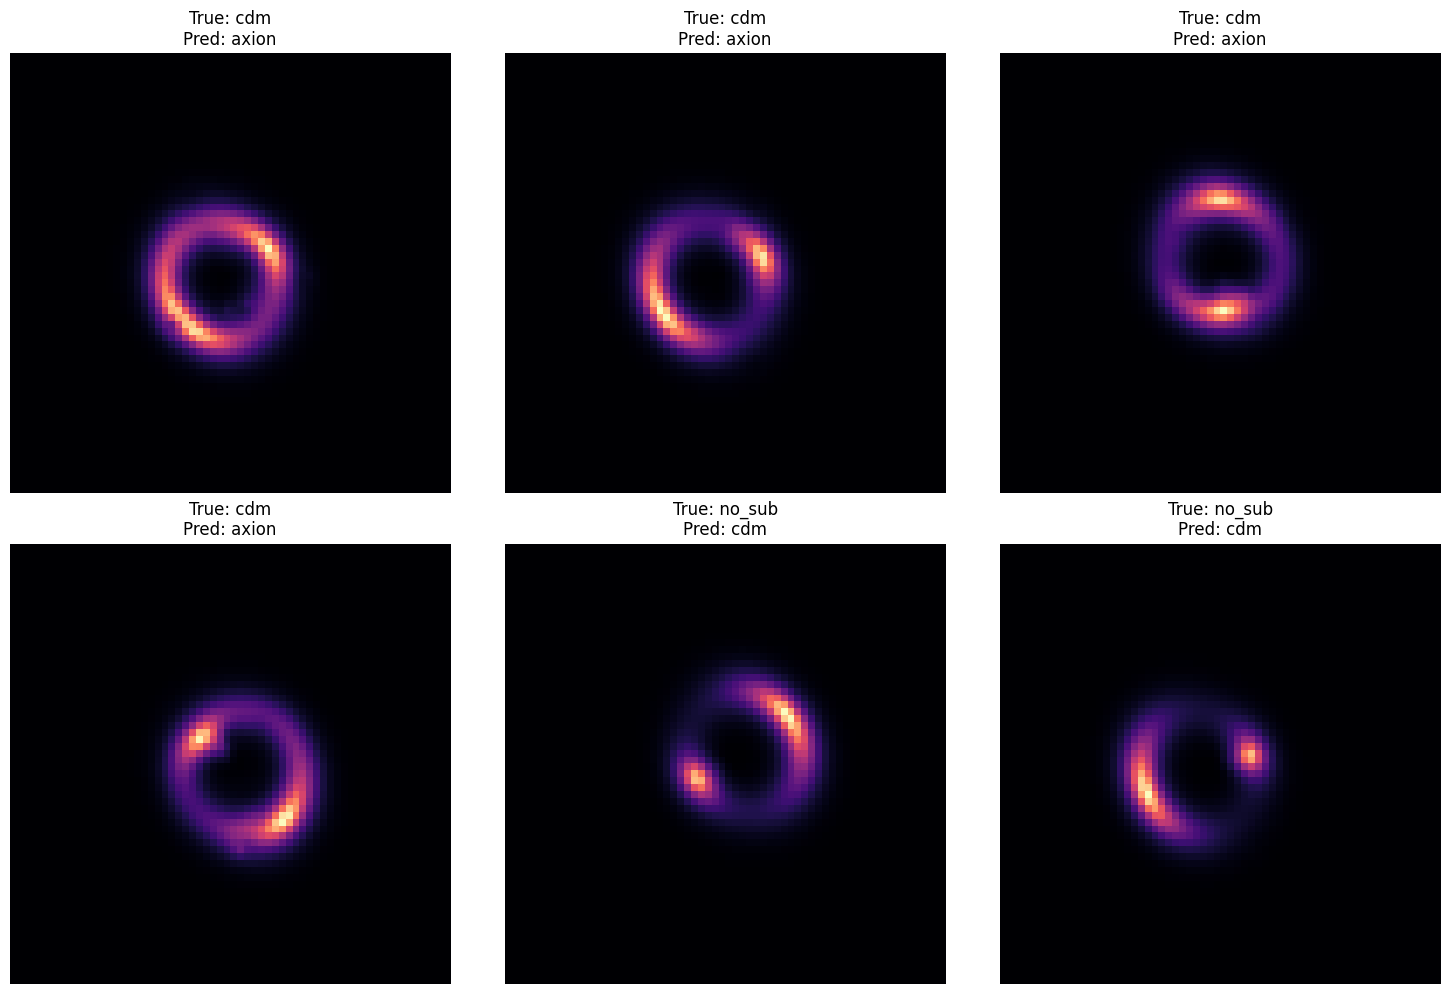

In [9]:
# Visualize Misclassified Samples
mis_idx = np.where(preds != labels)[0]
if len(mis_idx) > 0:
    sel_idx = np.random.choice(mis_idx, min(6, len(mis_idx)), replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, idx in enumerate(sel_idx):
        ax = axes[i//3, i%3]
        img_data = np.load(ts_paths[idx], allow_pickle=True)
        img = img_data[0] if isinstance(img_data, (list, tuple, np.ndarray)) and len(img_data) == 2 else img_data
        img = img.astype(np.float32)
        if img.max() > img.min():
            img = (img - img.min()) / (img.max() - img.min())
            
        ax.imshow(img, cmap='magma')
        ax.set_title(f"True: {CLASSES[labels[idx]]}\nPred: {CLASSES[preds[idx]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples found on the test set!")

### MAE Reconstruction Visualization

A useful way to check whether the MAE learned meaningful representations is to visualize its reconstructions.

For a few test images, the figure below shows:

1. The original image  
2. The masked input (90% of patches removed)  
3. The reconstructed image produced by the model  

Although the reconstruction is not perfectly smooth, the model is able to recover the overall ring structure. This indicates that the encoder has learned the global geometry of the lensing arcs.

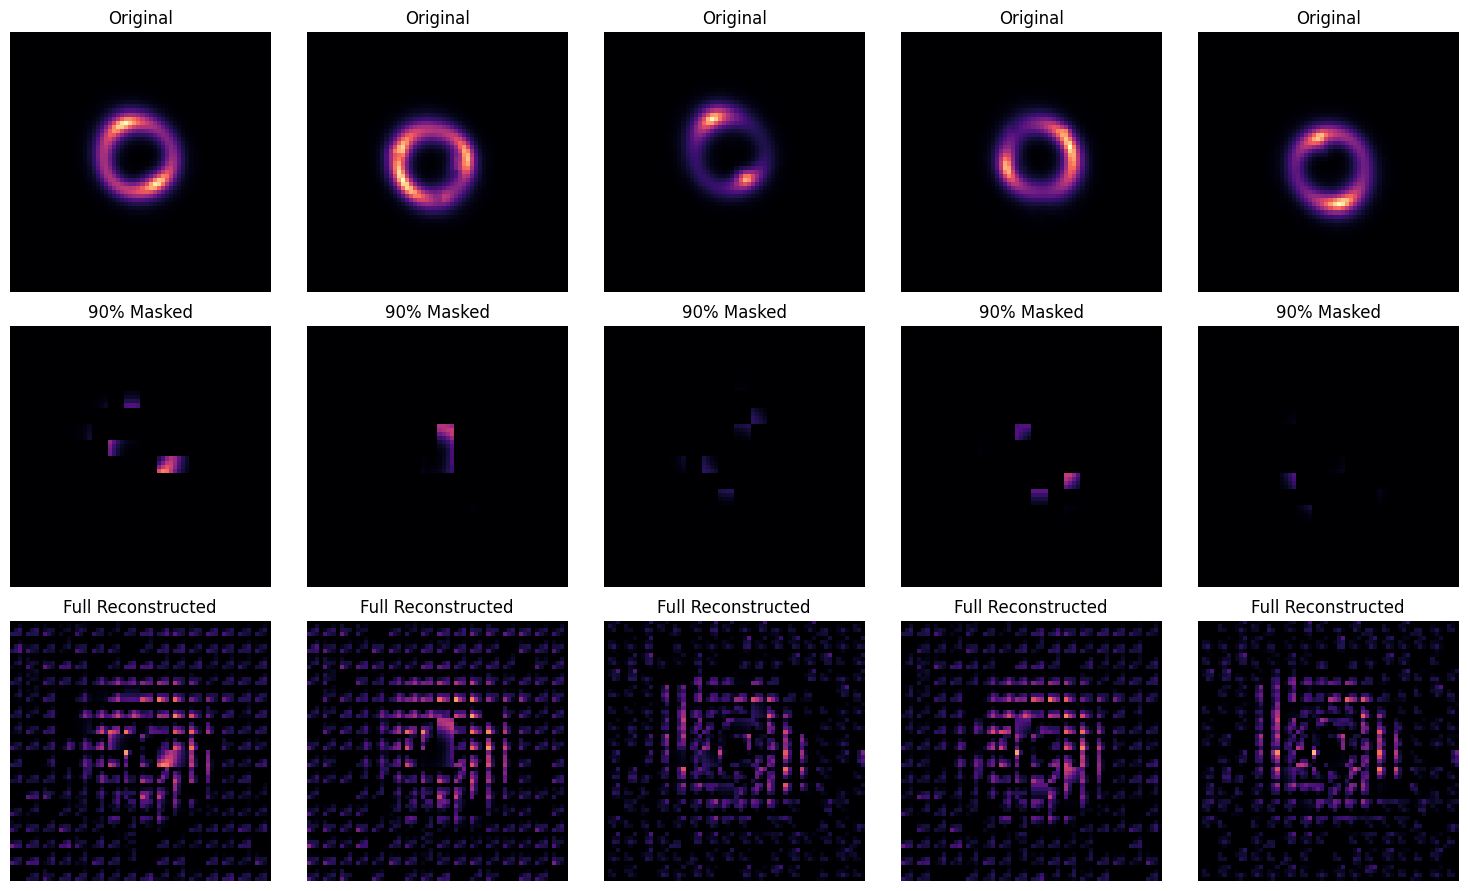

In [10]:
# Visualize MAE Reconstruction on Test Samples
mae_model.eval()
samples, _ = next(iter(test_loader))
samples = samples[:5].to(CONFIG["device"])

with torch.no_grad(), autocast(device_type="cuda"):
    loss, pred, mask = mae_model(samples)

# Reshape predicted patches back to image
p = CONFIG["patch_size"]
h = CONFIG["image_size"] // p
w = CONFIG["image_size"] // p

# Unpatchify prediction
pred_imgs = pred.reshape(pred.shape[0], h, w, p, p, 1)
pred_imgs = pred_imgs.permute(0, 5, 1, 3, 2, 4).reshape(pred.shape[0], 1, CONFIG["image_size"], CONFIG["image_size"])

# Create masked image for visualization
mask_vis = mask.detach().unsqueeze(-1).repeat(1, 1, p**2)
mask_vis = mask_vis.reshape(mask_vis.shape[0], h, w, p, p, 1)
mask_vis = mask_vis.permute(0, 5, 1, 3, 2, 4).reshape(mask_vis.shape[0], 1, CONFIG["image_size"], CONFIG["image_size"])
masked_imgs = samples * (1 - mask_vis)

# FULL RECONSTRUCTION: Combine visible patches + reconstructed masked patches
reconstructed = masked_imgs + pred_imgs * mask_vis

# Plotting
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Standardize scale [0, 1] with magma
    axes[0, i].imshow(samples[i, 0].cpu(), cmap='magma', vmin=0, vmax=1)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(masked_imgs[i, 0].cpu(), cmap='magma', vmin=0, vmax=1)
    axes[1, i].set_title("90% Masked")
    axes[1, i].axis('off')
    
    axes[2, i].imshow(reconstructed[i, 0].cpu(), cmap='magma', vmin=0, vmax=1)
    axes[2, i].set_title("Full Reconstructed")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

### Feature Space Visualization (t-SNE)

To better understand the representations learned by the encoder, the CLS token embeddings are projected into two dimensions using **t-SNE**.

If the encoder has learned meaningful features, images belonging to the same class should form clusters in this low-dimensional space.

In the visualization below, the **no_sub images form a clear cluster**, while **cdm and axion partially overlap**, which reflects the similarity of their substructure patterns.

Extracting Embeddings: 100%|██████████| 140/140 [00:05<00:00, 26.39it/s]


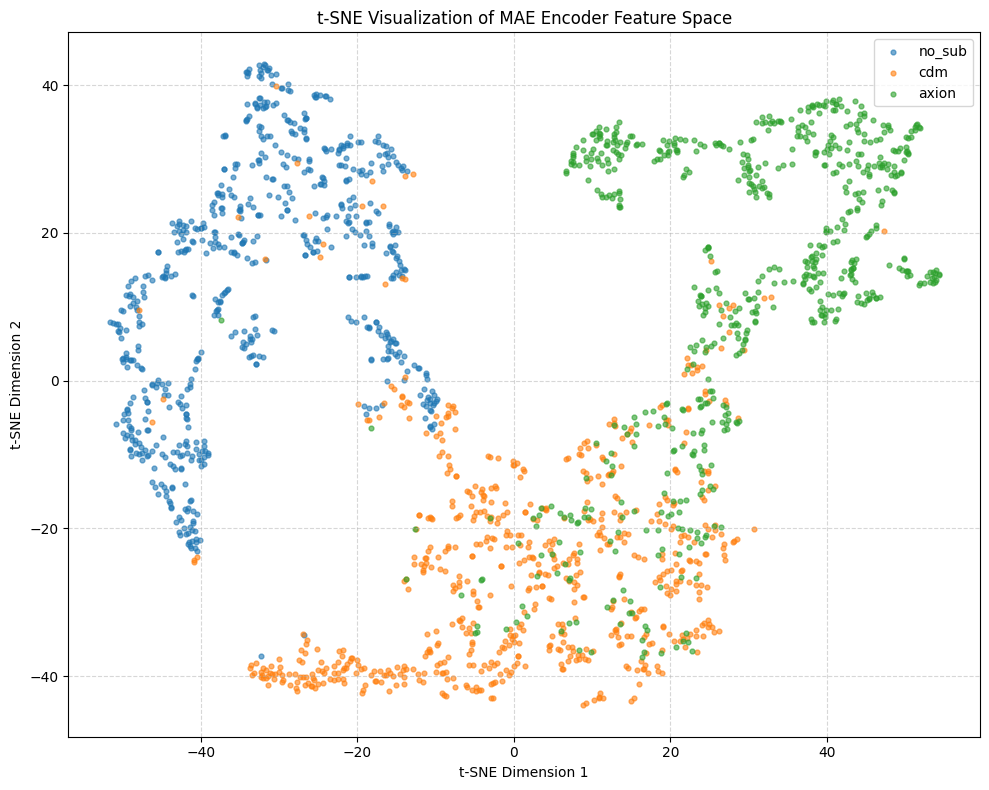

In [11]:
from sklearn.manifold import TSNE

# Extract CLS embeddings for t-SNE
clf_model.eval()
embeddings, targets = [], []

with torch.no_grad(), autocast(device_type="cuda"):
    for imgs, labels in tqdm(test_loader, desc="Extracting Embeddings"):
        imgs = imgs.to(CONFIG["device"])
        # Extract features (CLS token) before the classification head
        x = clf_model.patch_embed(imgs)
        x = x + clf_model.pos_embed[:, 1:, :]
        cls = clf_model.cls_token + clf_model.pos_embed[:, :1, :]
        x = torch.cat((cls.expand(x.shape[0], -1, -1), x), dim=1)
        feat = clf_model.encoder(x)[:, 0]
        
        embeddings.append(feat.cpu())
        targets.append(labels)

embeddings = torch.cat(embeddings).numpy()
targets = torch.cat(targets).numpy()

# IMPROVEMENT: Use subset for efficiency
max_points = 2000
embeddings = embeddings[:max_points]
targets = targets[:max_points]

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
vis_dims = tsne.fit_transform(embeddings)

# Plotting
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
for i, cls_name in enumerate(CLASSES):
    idx = (targets == i)
    plt.scatter(vis_dims[idx, 0], vis_dims[idx, 1], c=colors[i], label=cls_name, alpha=0.6, s=12)

plt.legend()
plt.title("t-SNE Visualization of MAE Encoder Feature Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Training Curve Visualization

The plots below show the training dynamics for both stages of the experiment.

The first plot tracks the **MAE reconstruction loss** during self-supervised pretraining.

The second plot shows the **cross-entropy loss** during classifier fine-tuning.

Both curves decrease steadily, indicating that the model converges smoothly during training.

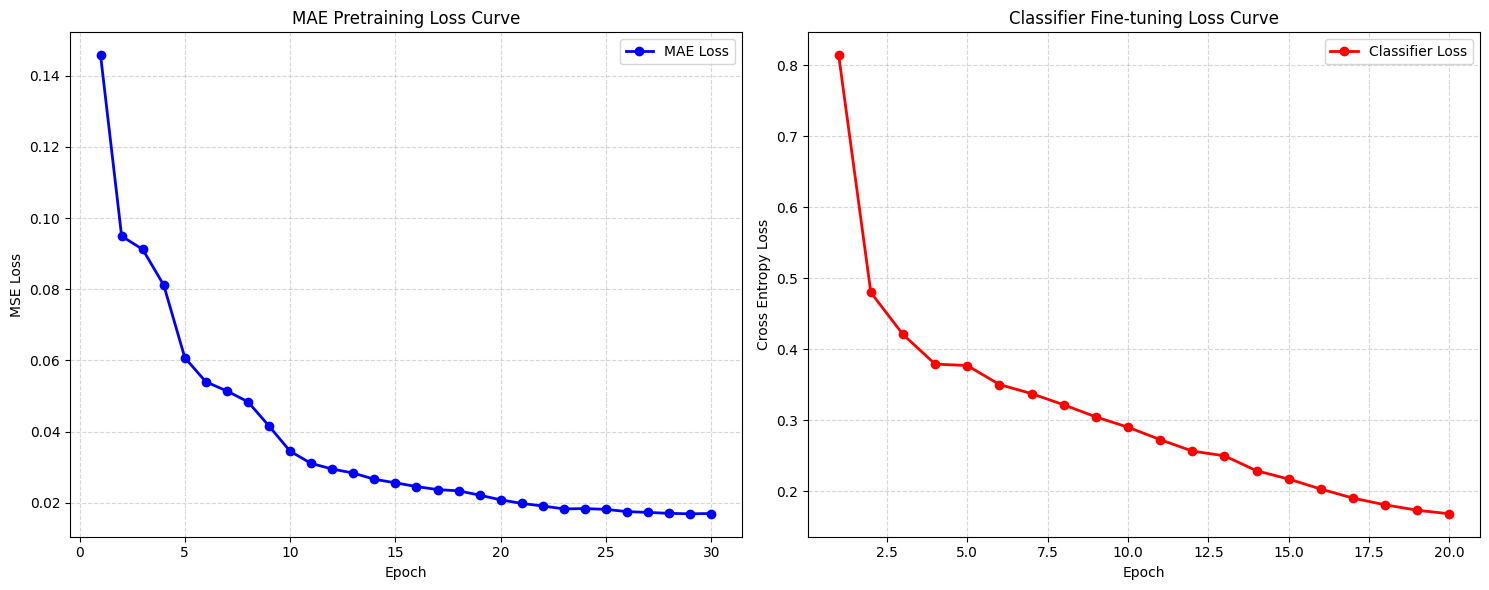

In [12]:
# Plot Training Curves
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].plot(range(1, len(mae_history)+1), mae_history, marker='o', color='blue', linewidth=2, label='MAE Loss')
ax[0].set_title("MAE Pretraining Loss Curve")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE Loss")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend()

ax[1].plot(range(1, len(clf_history)+1), clf_history, marker='o', color='red', linewidth=2, label='Classifier Loss')
ax[1].set_title("Classifier Fine-tuning Loss Curve")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Cross Entropy Loss")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()


Overall, the results show that MAE pretraining helps the transformer encoder learn useful representations of gravitational lensing images.

After fine-tuning, the model achieves strong performance in distinguishing between smooth lenses and lenses containing dark matter substructure.